# Deep Learning Project: Handwritten Digit Classifier (MNIST)

###📌 Objective:

Build and evaluate a deep learning model that classifies handwritten digits (0–9) using the MNIST dataset. This project will reinforce core deep learning concepts such as data preprocessing, batch normalization, dropout regularization, and model evaluation through visual metrics.

##1. Dataset Loading

Use the MNIST dataset available directly from TensorFlow/Keras.

Command to load the data:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [31]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


## 2. Preprocessing

Normalize the input data (x_train, x_test) to the range [0, 1].

Flatten the 28x28 images if using a dense neural network.



###Pixel Values Before Normalization

In [32]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


###Normalize the input data

In [33]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Pixel Values After Normalization

In [34]:
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


###Flatten the Images

In [35]:
x_train_flat = x_train.reshape(60000, 784)
x_test_flat = x_test.reshape(10000, 784)

###Verify the New Shape

In [36]:
print("Original Shape:", x_train.shape)
print("Flattened Shape:", x_train_flat.shape)

Original Shape: (60000, 28, 28)
Flattened Shape: (60000, 784)


###Prepare the Labels

In [37]:
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]


In [38]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [39]:
print("Original Label:", y_train[0])
print("One-Hot Label:", y_train_cat[0])

Original Label: 5
One-Hot Label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 3. Model Architecture

Build a deep neural network using TensorFlow/Keras.

Your model must include:

2–3 Hidden Layers

Batch Normalization layers after at least one or more hidden layers

Dropout to reduce overfitting (apply it after some layers)



In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

In [41]:
model = Sequential([

    # Input + Hidden Layer 1
    Dense(256, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

## 4. Training

Compile the model with appropriate loss and optimizer (categorical_crossentropy, adam, etc.).

Train with validation split.

Train for multiple epochs (e.g., 10–20), and collect history for plotting.



###Compile the Model

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

###Train the Model

In [44]:
history = model.fit(
    x_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8568 - loss: 0.4736 - val_accuracy: 0.9536 - val_loss: 0.1560
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9383 - loss: 0.2091 - val_accuracy: 0.9642 - val_loss: 0.1162
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9515 - loss: 0.1653 - val_accuracy: 0.9682 - val_loss: 0.1064
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9608 - loss: 0.1321 - val_accuracy: 0.9696 - val_loss: 0.0988
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9650 - loss: 0.1172 - val_accuracy: 0.9730 - val_loss: 0.0950
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9680 - loss: 0.1062 - val_accuracy: 0.9746 - val_loss: 0.0843
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9705 - loss: 0.0977 - val_accuracy: 0.9748 - val_loss: 0.0857
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9727 - loss: 0.0874 - val_accu

## 5. Visualization

Plot training vs. validation accuracy over epochs.

Optional: Also plot training vs. validation loss.



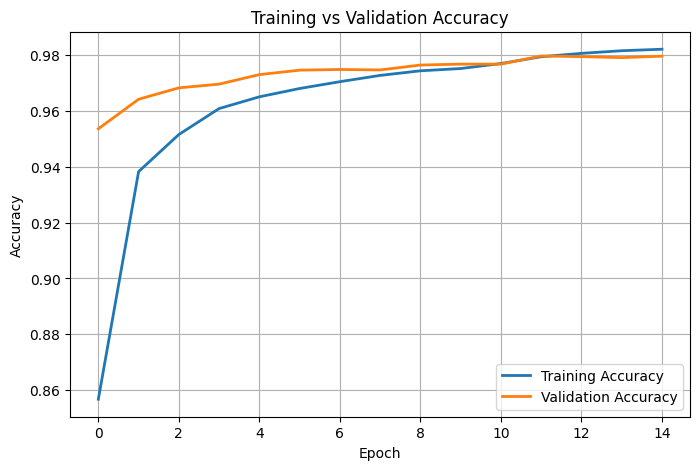

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

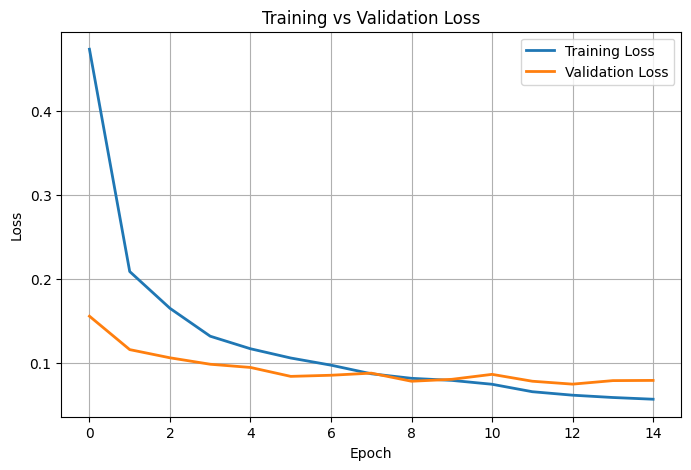

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

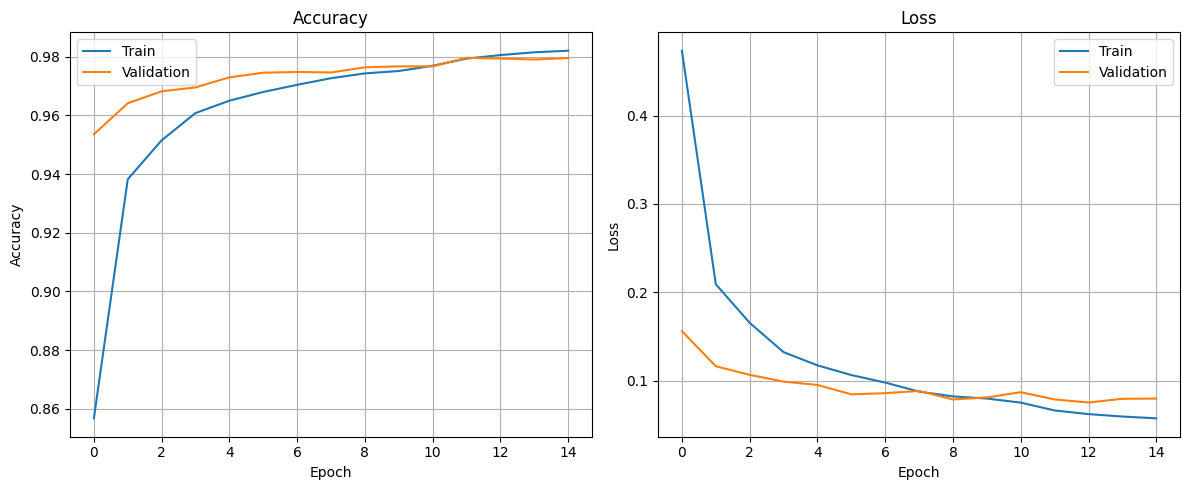

In [47]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


##Accuracy Plot

The training accuracy increased steadily across epochs, while the validation accuracy followed a similar trend and remained close to the training curve. This indicates that the model successfully learned meaningful patterns from the MNIST dataset without significant overfitting.

##Loss Plot

The training and validation loss decreased consistently during training. Since the validation loss remained stable and did not increase significantly, the model demonstrated good generalization performance on unseen data.

## 6. Evaluation

Predict on the test set (x_test) and report final test accuracy.

###Evaluate the Model on Test Data

In [48]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_cat, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.0685
Test Loss: 0.0685
Test Accuracy: 0.9800


###Predict Individual Digits

In [49]:
predictions = model.predict(x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


###Convert Probabilities into Labels

In [50]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

###Compare Prediction with Actual Label

In [51]:
index = 0

print("Actual:", y_test[index])
print("Predicted:", predicted_labels[index])

Actual: 7
Predicted: 7


###Display One Prediction

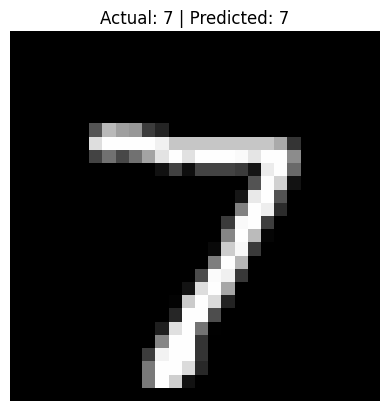

In [52]:
plt.imshow(x_test[index], cmap="gray")
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_labels[index]}")
plt.axis("off")
plt.show()

###Display Multiple Predictions

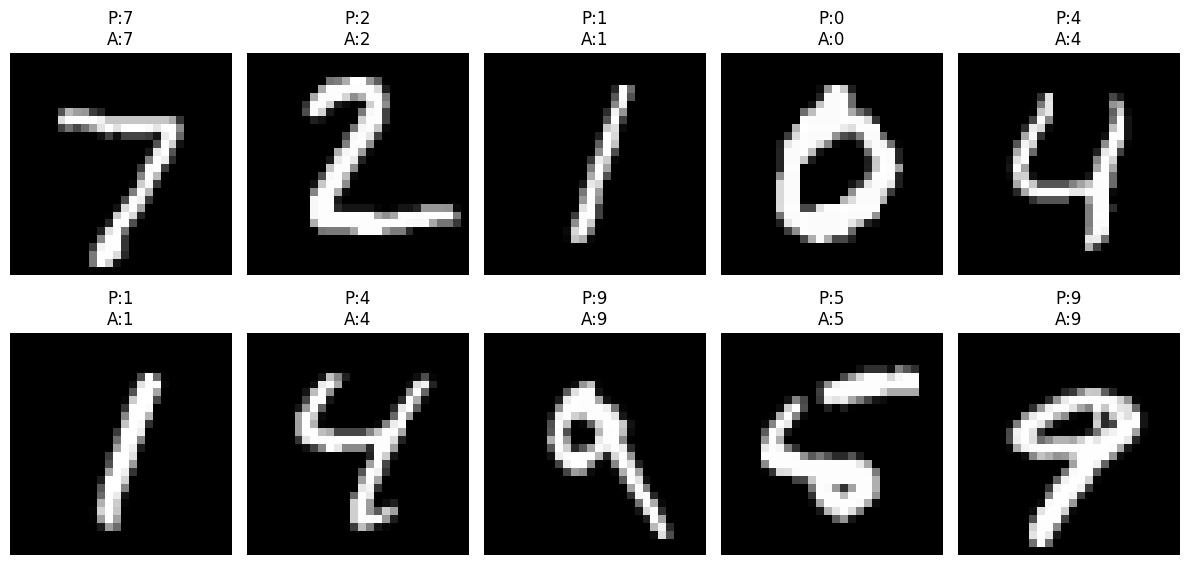

In [53]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i], cmap="gray")

    plt.title(f"P:{predicted_labels[i]}\nA:{y_test[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

###Display Incorrect Predictions

In [54]:
incorrect = np.where(predicted_labels != y_test)[0]

print("Number of incorrect predictions:", len(incorrect))

Number of incorrect predictions: 200


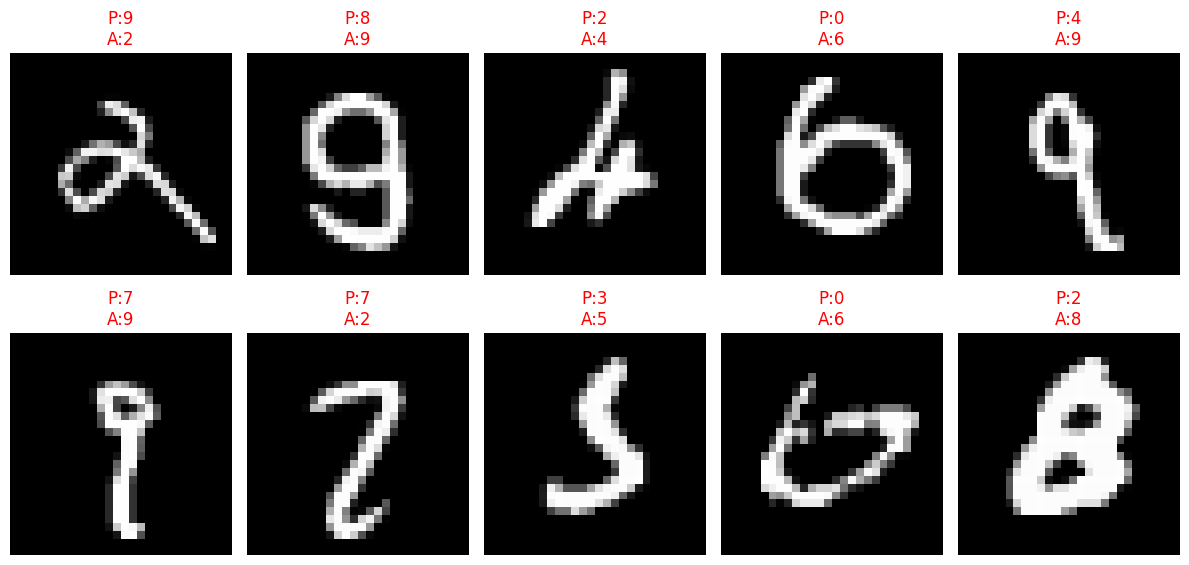

In [55]:
plt.figure(figsize=(12,6))

for i in range(10):
    idx = incorrect[i]

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx], cmap="gray")

    plt.title(f"P:{predicted_labels[idx]}\nA:{y_test[idx]}", color="red")

    plt.axis("off")

plt.tight_layout()
plt.show()

###Confusion Matrix

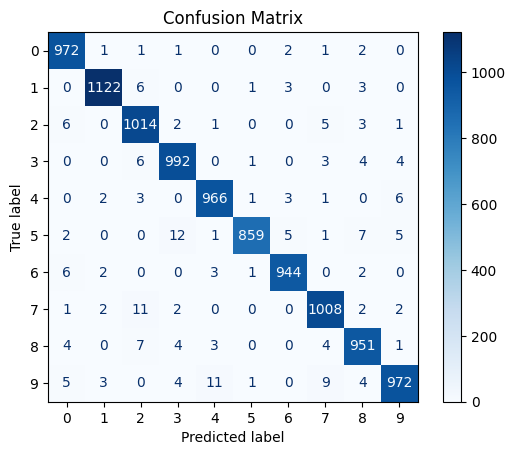

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

###Classification Report

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.96      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



##Test Accuracy

The trained deep neural network achieved a high accuracy on the unseen MNIST test dataset, demonstrating strong generalization performance. This indicates that the model successfully learned meaningful handwritten digit patterns rather than simply memorizing the training data.

##Prediction Results

Most handwritten digits were classified correctly, while only a small number of ambiguous or poorly written digits were misclassified. Visualizing both correct and incorrect predictions helped identify the model's strengths and common error patterns.

##Confusion Matrix

The confusion matrix showed that most predictions were concentrated along the diagonal, indicating correct classifications across nearly all digit classes. Only a few visually similar digits were occasionally confused with one another.